# ATN DAC Quality Control Example - Trajectory Data

This notebook demonstrates how to apply QARTOD quality control tests to Animal Telemetry Network (ATN) satellite telemetry trajectory data using the [`ioos_qc`](https://github.com/ioos/ioos_qc) Python package.

## Background

The ATN DAC applies automated quality control to all auto-ingested trajectory and profile data from Wildlife Computers and SMRU instruments. This notebook shows the exact tests and thresholds used in our operational pipeline, allowing users to:

1. Understand what QC is being applied to ATN data
2. Replicate the QC process on their own data
3. Interpret the QARTOD flags embedded in ATN data products

### QC Tests Applied to Trajectory Data

| Test | Module | Suspect Threshold | Fail Threshold |
|------|--------|-------------------|----------------|
| Speed Test | `ioos_qc.argo.speed_test` | > 8.0 m/s | > 10.0 m/s |
| Location Test | `ioos_qc.qartod.location_test` | n/a | Outside [-180, -90, 180, 90] |
| Time Valid Range | `ioos_qc.axds.valid_range_test` | n/a | Outside deployment dates |

### QC Tests Applied to Profile Data

| Test | Variable | Fail Range | Description |
|------|----------|------------|-------------|
| `gross_range_test` | Temperature | [-2.5, 40] °C | Physical bounds for seawater temperature |
| `gross_range_test` | Salinity | [0, 41] PSU | Physical bounds for seawater salinity |
| `valid_range_test` | Time | Deployment period | Flags data outside deployment dates |

### QARTOD Flag Values

| Flag | Meaning |
|------|---------|
| 1 | PASS - Data passed all QC tests |
| 2 | NOT_EVALUATED - Test not performed |
| 3 | SUSPECT - Data questionable, use with caution |
| 4 | FAIL - Data failed QC, should not be used |
| 9 | MISSING - Data is missing |

**References:**
- [ATN Satellite Telemetry Specification v1.0](https://ioos.github.io/ioos-atn-data/atn-sat-telem-specification-v1-0.html)
- [ioos_qc Documentation](https://ioos.github.io/ioos_qc/)
- [Argo Quality Control Manual](https://archimer.ifremer.fr/doc/00228/33951/)
  

### Implementation Note

> **Discrepancy with Documentation:** Recent discussion in [GitHub issue #14](https://github.com/ioos/marine_life_data_network/issues/14) mentions additional QC tests for profile data: `pressure_increasing_test`, `spike_test`, and "positions on land" checking. However, as of this writing, these tests are **not currently implemented** in the packrat codebase (`packrat/platforms/utils.py`). This notebook documents only the tests that ARE implemented in the operational pipeline. The team should clarify whether additional tests are planned for future releases.

## 1. Import Required Libraries

In [30]:
# Core data handling
import pandas as pd
import numpy as np
import io
import zipfile
import requests

# QC libraries
from ioos_qc.config import Config
from ioos_qc.streams import PandasStream
from ioos_qc.stores import PandasStore
from ioos_qc.utils import great_circle_distance

# Visualization
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 2. Fetch ATN Trajectory Data

We'll use **real deployment data** from the ATN Data Assembly Center. This example uses deployment **254060O2024** which contains Wildlife Computers satellite tag data.

The data is accessed directly from the ATN data portal at [portal.atn.ioos.us](https://portal.atn.ioos.us).

### Wildlife Computers Data Format

Wildlife Computers tags produce several data types:
- **Argos** - Satellite-derived positions with location class quality indicators
- **FastGPS** - Higher-accuracy GPS positions (when available)
- **Series** - Time-series data (temperature, depth)
- **Histos** - Histogram summaries of behavior

For trajectory QC, we primarily use the **Argos** position data which includes:
- Date/time of each position fix
- Latitude and Longitude
- Location Class (quality indicator: 3, 2, 1, 0, A, B, Z)
- Error ellipse parameters

In [31]:
# Download real ATN deployment data from Wildlife Computers
# This is deployment 254060O2024 - a real tagged animal track

deployment_url = "https://workspace.aoos.org/published/file/1989e709-af65-4250-9413-637d5cea36f4/254053O2024.zip?source=catalog&portalId=99"
# deployment_url = "https://workspace.aoos.org/published/file/9d318aa0-e818-4473-90d5-157c0f3dd186/254060O2024.zip?source=catalog&portalId=99"


print(f"Downloading deployment data from ATN...")
response = requests.get(deployment_url)
response.raise_for_status()

# Extract the ZIP file contents
zip_buffer = io.BytesIO(response.content)
zf = zipfile.ZipFile(zip_buffer)

# List files in the ZIP
print(f"\nFiles in deployment ZIP:")
for filename in sorted(zf.namelist()):
    print(f"  - {filename}")


Files in deployment ZIP:
  - 254053O2024/
  - 254053O2024/254053-10-GPE3.csv
  - 254053O2024/254053-10-GPE3.kmz
  - 254053O2024/254053-10-GPE3.nc
  - 254053O2024/254053-All.csv
  - 254053O2024/254053-Argos.csv
  - 254053O2024/254053-Corrupt.csv
  - 254053O2024/254053-Histos.csv
  - 254053O2024/254053-Labels.csv
  - 254053O2024/254053-LightLoc.csv
  - 254053O2024/254053-Locations.csv
  - 254053O2024/254053-MinMaxDepth.csv
  - 254053O2024/254053-MixLayer.csv
  - 254053O2024/254053-PDTs.csv
  - 254053O2024/254053-RTC.csv
  - 254053O2024/254053-RawArgos.csv
  - 254053O2024/254053-SST.csv
  - 254053O2024/254053-Series.csv
  - 254053O2024/254053-SeriesRange.csv
  - 254053O2024/254053-Status.csv
  - 254053O2024/254053-Summary.csv
  - 254053O2024/254053.kmz
  - 254053O2024/254053.prv
  - 254053O2024/254053.pxp
  - 254053O2024/setup.rtf
  - 254053O2024/sources.txt


In [32]:
# Load the Argos position data in the Locations file for trajectory QC

argos_file = None
for filename in zf.namelist():
    if '-Locations.csv' in filename or filename.endswith('Locations.csv'):
        argos_file = filename
        break

if argos_file:
    print(f"Loading Argos data from: {argos_file}")
    with zf.open(argos_file) as f:
        trajectory_df = pd.read_csv(f)
    
    print(f"\nLoaded {len(trajectory_df)} trajectory points")
    print(f"\nColumns in Argos file:")
    for col in trajectory_df.columns:
        print(f"  - {col}")
else:
    # If no Argos file, look for any position data
    print("No Argos file found, searching for position data...")
    for filename in zf.namelist():
        if filename.endswith('.csv'):
            print(f"  Checking: {filename}")
            with zf.open(filename) as f:
                df_check = pd.read_csv(f, nrows=5)
                if 'Latitude' in df_check.columns or 'latitude' in df_check.columns.str.lower():
                    print(f"  -> Found position data!")
                    with zf.open(filename) as f2:
                        trajectory_df = pd.read_csv(f2)
                    break

Loading Argos data from: 254053O2024/254053-Locations.csv

Loaded 629 trajectory points

Columns in Argos file:
  - DeployID
  - Ptt
  - Instr
  - Date
  - Type
  - Quality
  - Latitude
  - Longitude
  - Error radius
  - Error Semi-major axis
  - Error Semi-minor axis
  - Error Ellipse orientation
  - Offset
  - Offset orientation
  - GPE MSD
  - GPE U
  - Count
  - Comment


In [33]:
# Examine the trajectory data structure
print("Data shape:", trajectory_df.shape)
print(f"\nDate range: {trajectory_df['Date'].min()} to {trajectory_df['Date'].max()}")

# Show first few records
print("\nFirst 5 records:")
trajectory_df.head()

Data shape: (629, 18)

Date range: 00:02:32 06-Apr-2024 to 23:59:54 03-Apr-2024

First 5 records:


,DeployID,Ptt,Instr,Date,Type,Quality,Latitude,Longitude,Error radius,Error Semi-major axis,Error Semi-minor axis,Error Ellipse orientation,Offset,Offset orientation,GPE MSD,GPE U,Count,Comment
0,254053,254053,MiniPAT,02:03:56 31-Mar-2024,Argos,0,11.8863,-100.2372,4738,13416.0,1673.0,28.0,NaN,NaN,NaN,NaN,NaN,NaN
1,254053,254053,MiniPAT,02:30:43 31-Mar-2024,Argos,2,11.9007,-100.2494,347,454.0,264.0,60.0,NaN,NaN,NaN,NaN,NaN,NaN
2,254053,254053,MiniPAT,03:03:54 31-Mar-2024,Argos,1,11.9024,-100.2447,901,2404.0,337.0,49.0,NaN,NaN,NaN,NaN,NaN,NaN
3,254053,254053,MiniPAT,03:40:08 31-Mar-2024,Argos,1,11.8957,-100.2561,704,1801.0,275.0,81.0,NaN,NaN,NaN,NaN,NaN,NaN
4,254053,254053,MiniPAT,04:27:03 31-Mar-2024,Argos,2,11.8882,-100.2766,425,767.0,235.0,84.0,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Explore the Trajectory Data

Let's examine the data to understand what we're working with before applying QC.

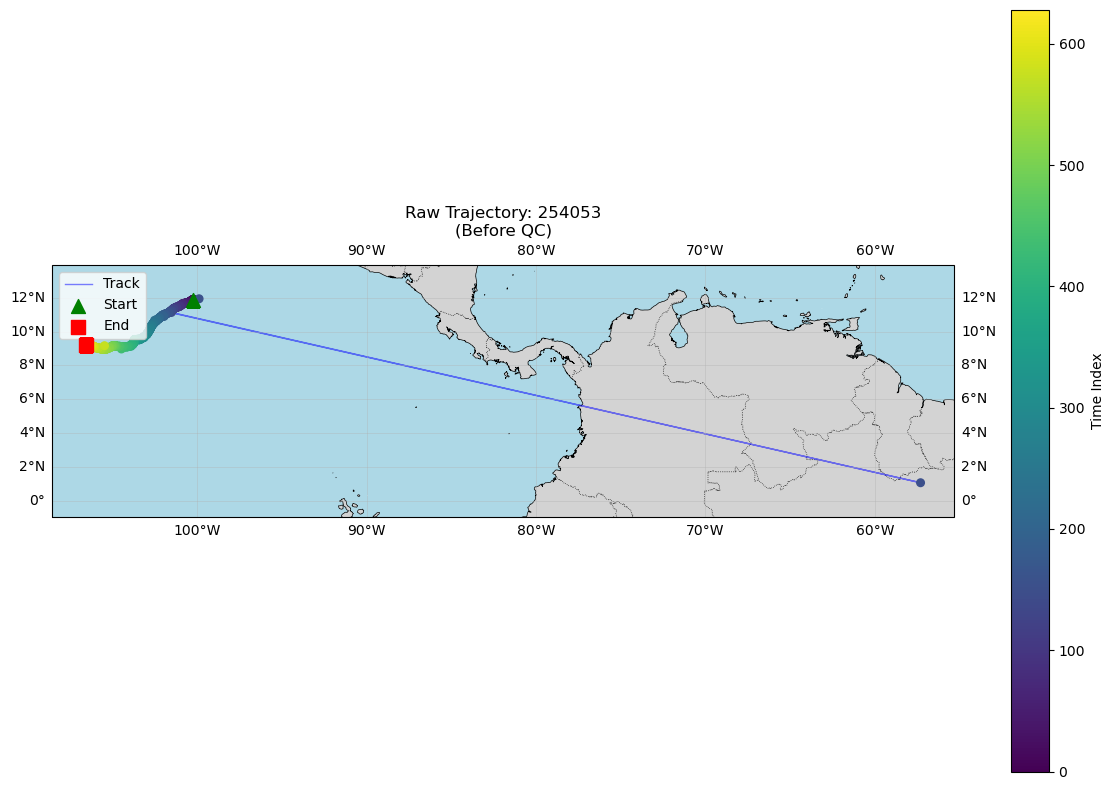


Total points: 629, Valid coordinates: 629


In [35]:
# Visualize the raw track before QC
fig, ax = plt.subplots(1, 1, figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Find lat/lon columns
lat_col = [c for c in trajectory_df.columns if 'lat' in c.lower()][0]
lon_col = [c for c in trajectory_df.columns if 'lon' in c.lower()][0]

# Filter valid coordinates for extent calculation
valid_mask = (trajectory_df[lat_col].between(-90, 90)) & (trajectory_df[lon_col].between(-180, 180))
valid_data = trajectory_df[valid_mask]

# Set map extent with some padding
lon_min, lon_max = valid_data[lon_col].min() - 2, valid_data[lon_col].max() + 2
lat_min, lat_max = valid_data[lat_col].min() - 2, valid_data[lat_col].max() + 2

ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)

# Plot trajectory
ax.plot(valid_data[lon_col], valid_data[lat_col],
        'b-', linewidth=1, alpha=0.5, transform=ccrs.PlateCarree(), label='Track')
map = ax.scatter(valid_data[lon_col], valid_data[lat_col], 
           c=range(len(valid_data)), cmap='viridis', s=30, 
           transform=ccrs.PlateCarree(), zorder=5)
plt.colorbar(map, ax=ax, orientation='vertical', label='Time Index')

# Mark start and end
ax.scatter(valid_data[lon_col].iloc[0], valid_data[lat_col].iloc[0],
           c='green', s=100, marker='^', transform=ccrs.PlateCarree(), 
           zorder=10, label='Start')
ax.scatter(valid_data[lon_col].iloc[-1], valid_data[lat_col].iloc[-1],
           c='red', s=100, marker='s', transform=ccrs.PlateCarree(), 
           zorder=10, label='End')

# Get deployment ID if available
deploy_id = trajectory_df['DeployID'].iloc[0] if 'DeployID' in trajectory_df.columns else 'Unknown'

ax.legend(loc='upper left')
ax.set_title(f"Raw Trajectory: {deploy_id}\n(Before QC)")
plt.tight_layout()
plt.show()

print(f"\nTotal points: {len(trajectory_df)}, Valid coordinates: {len(valid_data)}")

## 4. Configure QARTOD QC Tests

Now we'll configure the QC tests using `ioos_qc`. The ATN DAC applies the following tests to trajectory data:

### Location Test
Checks that positions fall within valid geographic bounds:
- **Bounding Box**: [-180, -90, 180, 90] (global ocean)
- For regional studies, tighter bounds may be used

### Speed Test  
Checks for biologically implausible movement speeds:
- **Suspect threshold**: 8.0 m/s - fast but possible for some species
- **Fail threshold**: 10.0 m/s - physically impossible for most marine animals

These thresholds are adapted from Argo float protocols but adjusted for marine animal movement capabilities.

In [36]:
# Prepare data for QC
# Standardize column names and convert datetime

# Find the relevant columns
lat_col = [c for c in trajectory_df.columns if 'lat' in c.lower()][0]
lon_col = [c for c in trajectory_df.columns if 'lon' in c.lower()][0]
date_col = [c for c in trajectory_df.columns if 'date' in c.lower()][0]

# Create QC dataframe with standardized names
qc_df = trajectory_df.copy()
qc_df['lat'] = qc_df[lat_col]
qc_df['lon'] = qc_df[lon_col]

# Parse datetime
qc_df['time'] = pd.to_datetime(qc_df[date_col])
qc_df = qc_df.sort_values('time').reset_index(drop=True)

# Convert to Unix timestamp for speed calculations
qc_df['timestamp'] = qc_df['time'].astype('int64') / 1e9

print("Data prepared for QC:")
print(f"  Records: {len(qc_df)}")
print(f"  Date range: {qc_df['time'].min()} to {qc_df['time'].max()}")
print(f"  Lat range: {qc_df['lat'].min():.3f} to {qc_df['lat'].max():.3f}")
print(f"  Lon range: {qc_df['lon'].min():.3f} to {qc_df['lon'].max():.3f}")

qc_df[['time', 'lat', 'lon', 'timestamp']].head()

Data prepared for QC:
  Records: 629
  Date range: 2024-03-31 02:03:56 to 2024-04-19 04:35:53
  Lat range: 1.075 to 11.940
  Lon range: -106.586 to -57.298


,time,lat,lon,timestamp
0,2024-03-31 02:03:56,11.8863,-100.2372,1.711851e+09
1,2024-03-31 02:30:43,11.9007,-100.2494,1.711852e+09
2,2024-03-31 03:03:54,11.9024,-100.2447,1.711854e+09
3,2024-03-31 03:40:08,11.8957,-100.2561,1.711856e+09
4,2024-03-31 04:27:03,11.8882,-100.2766,1.711859e+09


In [37]:
# QC Test Thresholds used by ATN DAC
# These are defined based on biological plausibility for marine animals

QC_THRESHOLDS = {
    'location_test': {
        'bbox': [-180, -90, 180, 90],  # Global ocean bounds [lon_min, lat_min, lon_max, lat_max]
        'description': 'Flags positions outside valid geographic range'
    },
    'speed_test': {
        'suspect_threshold': 8.0,  # m/s - high speed, possibly valid for fast swimmers
        'fail_threshold': 10.0,    # m/s - biologically impossible for most marine animals
        'description': 'Flags unrealistic movement speeds between consecutive positions'
    }
}

# Display thresholds
print("ATN DAC QC Thresholds for Trajectory Data")
print("="*50)
for test_name, params in QC_THRESHOLDS.items():
    print(f"\n{test_name}:")
    print(f"  Description: {params['description']}")
    for k, v in params.items():
        if k != 'description':
            print(f"  {k}: {v}")

ATN DAC QC Thresholds for Trajectory Data

location_test:
  Description: Flags positions outside valid geographic range
  bbox: [-180, -90, 180, 90]

speed_test:
  Description: Flags unrealistic movement speeds between consecutive positions
  suspect_threshold: 8.0
  fail_threshold: 10.0


## 5. Execute QC Tests

Now we'll run the QARTOD QC tests using `ioos_qc`. We'll apply:

1. **Location Test** - Validates that coordinates fall within valid geographic bounds
2. **Speed Test** - Calculates velocity between consecutive points and flags unrealistic speeds

The tests are run directly using the `ioos_qc.qartod` and `ioos_qc.argo` modules.

In [38]:
# Run Location Test
from ioos_qc.qartod import location_test

location_flags = location_test(
    lon=qc_df['lon'].values,
    lat=qc_df['lat'].values,
    bbox=QC_THRESHOLDS['location_test']['bbox']
)

qc_df['location_test'] = location_flags

print("Location test completed!")
print(f"\nLocation test flag distribution:")
flag_names = {1: 'PASS', 2: 'NOT_EVAL', 3: 'SUSPECT', 4: 'FAIL', 9: 'MISSING'}
for flag, count in pd.Series(location_flags).value_counts().sort_index().items():
    print(f"  {flag_names.get(flag, 'UNK')} ({flag}): {count}")

# Show any failed locations
failed_locs = qc_df[qc_df['location_test'] == 4]
if len(failed_locs) > 0:
    print(f"\nPoints that failed location test: {len(failed_locs)}")
    print(failed_locs[['time', 'lat', 'lon', 'location_test']].head())
else:
    print("\n✓ All positions passed the location test")

Location test completed!

Location test flag distribution:
  PASS (1): 629

✓ All positions passed the location test


In [39]:
# Run speed test - calculates velocity between consecutive points
from ioos_qc.argo import speed_test

dist = great_circle_distance(qc_df['lat'].values, qc_df['lon'].values)
time_diff = np.diff(qc_df['timestamp'].values)
calculated_speed = np.zeros(len(qc_df))
calculated_speed[1:] = np.abs(dist[1:] / time_diff)

# Calculate speeds for plotting (this is done internally in ioos_qc)
qc_df['calculated_speed'] = calculated_speed

# Run ioos_qc speed test
speed_flags = speed_test(
    lon=qc_df['lon'].values,
    lat=qc_df['lat'].values,
    tinp=qc_df['timestamp'].values,
    suspect_threshold=8.0,
    fail_threshold=10.0
)

qc_df['speed_test'] = speed_flags

print("Speed test completed!")
print(f"\nSpeed statistics (m/s):")
print(f"  Min: {qc_df['calculated_speed'].min():.4f}")
print(f"  Max: {qc_df['calculated_speed'].max():.4f}")
print(f"  Mean: {qc_df['calculated_speed'].mean():.4f}")
print(f"  Median: {qc_df['calculated_speed'].median():.4f}")

# Show flag distribution
print(f"\nSpeed test flag distribution:")
flag_names = {1: 'PASS', 2: 'NOT_EVAL', 3: 'SUSPECT', 4: 'FAIL', 9: 'MISSING'}
for flag, count in pd.Series(speed_flags).value_counts().sort_index().items():
    print(f"  {flag_names.get(flag, 'UNK')} ({flag}): {count}")

Speed test completed!

Speed statistics (m/s):
  Min: 0.0000
  Max: 56499.0716
  Mean: 99.9178
  Median: 0.7894

Speed test flag distribution:
  PASS (1): 577
  NOT_EVAL (2): 1
  SUSPECT (3): 6
  FAIL (4): 45


## 6. Interpret QARTOD Flags

The QC tests produce standardized QARTOD flag values. Let's create a summary of results and understand what each flag means for our data quality.

In [40]:
# Create an aggregate QC flag
# The aggregate takes the worst (highest) flag from all tests

qc_df['qc_aggregate'] = np.maximum(qc_df['location_test'], qc_df['speed_test'])

# Summary statistics
print("="*60)
print("QARTOD QC SUMMARY")
print("="*60)
print(f"\nTotal trajectory points: {len(qc_df)}")
print(f"\n{'Test':<20} {'Pass':<10} {'Suspect':<10} {'Fail':<10}")
print("-"*50)

for test_name in ['location_test', 'speed_test', 'qc_aggregate']:
    flags = qc_df[test_name]
    n_pass = (flags == 1).sum()
    n_suspect = (flags == 3).sum()
    n_fail = (flags == 4).sum()
    print(f"{test_name:<20} {n_pass:<10} {n_suspect:<10} {n_fail:<10}")

print("\n" + "="*60)

# Calculate pass rate
good_data = (qc_df['qc_aggregate'] == 1).sum()
suspect_data = (qc_df['qc_aggregate'] == 3).sum()
fail_data = (qc_df['qc_aggregate'] == 4).sum()

print(f"\nData Quality Summary:")
print(f"  Good data (flag=1):     {good_data:4d} ({100*good_data/len(qc_df):.1f}%)")
print(f"  Suspect data (flag=3):  {suspect_data:4d} ({100*suspect_data/len(qc_df):.1f}%)")
print(f"  Failed data (flag=4):   {fail_data:4d} ({100*fail_data/len(qc_df):.1f}%)")

QARTOD QC SUMMARY

Total trajectory points: 629

Test                 Pass       Suspect    Fail      
--------------------------------------------------
location_test        629        0          0         
speed_test           577        6          45        
qc_aggregate         577        6          45        


Data Quality Summary:
  Good data (flag=1):      577 (91.7%)
  Suspect data (flag=3):     6 (1.0%)
  Failed data (flag=4):     45 (7.2%)


## Demo Batch QC

In [41]:
# Production QC approach for trajectory data using PandasStream
# This mirrors how packrat applies QC in production

def apply_trajectory_qc_packrat_style(df, qc_config_yaml):
    """
    Apply trajectory QC using the same approach as packrat.
    
    This function mirrors packrat/platforms/utils.py apply_qc()
    """
    config = Config(qc_config_yaml)
    stream = PandasStream(df)
    results = stream.run(config)
    
    store = PandasStore(
        results,
        axes={
            't': 'time',
            'x': 'lon',
            'y': 'lat'
        }
    )
    
    store.compute_aggregate(name='qartod_rollup_qc')
    results_df = store.save(write_data=False, write_axes=False)
    
    return pd.concat([df, results_df], axis=1)

# Build QC configuration YAML for trajectory (matching packrat defaults)
trajectory_qc_yaml = """
lon:
    qartod:
        location_test:
            bbox: [-180, -90, 180, 90]
            lat: lat
lat:
    argo:
        speed_test:
            tinp: timestamp
            lon: lon
            suspect_threshold: 8.0
            fail_threshold: 10.0
"""

print("Trajectory QC Configuration (YAML format):")
print(trajectory_qc_yaml)

# Run QC packrat-style
trajectory_qc_results = apply_trajectory_qc_packrat_style(qc_df, trajectory_qc_yaml)

print("\n" + "="*50)
print("Trajectory QC Results (packrat-style)")
print("="*50)

# Show QC columns added
qc_cols = [c for c in trajectory_qc_results.columns if 'test' in c.lower() or 'rollup' in c.lower()]
print(f"\nQC columns added: {qc_cols}")

# Show rollup summary
if 'qartod_rollup_qc' in trajectory_qc_results.columns:
    print(f"\nAggregate QC (qartod_rollup_qc) distribution:")
    flag_names = {1: 'PASS', 2: 'NOT_EVAL', 3: 'SUSPECT', 4: 'FAIL', 9: 'MISSING'}
    for flag, count in trajectory_qc_results['qartod_rollup_qc'].value_counts().sort_index().items():
        pct = 100 * count / len(trajectory_qc_results)
        print(f"  {flag_names.get(flag, 'UNK')} ({flag}): {count:5d} ({pct:.1f}%)")

Trajectory QC Configuration (YAML format):

lon:
    qartod:
        location_test:
            bbox: [-180, -90, 180, 90]
            lat: lat
lat:
    argo:
        speed_test:
            tinp: timestamp
            lon: lon
            suspect_threshold: 8.0
            fail_threshold: 10.0


Trajectory QC Results (packrat-style)

QC columns added: ['location_test', 'speed_test', 'lon_qartod_location_test', 'lat_argo_speed_test', 'qartod_qartod_rollup_qc']


## 7. Visualize QC Results

Let's create visualizations that show the QC results on our trajectory map and highlight flagged data points.

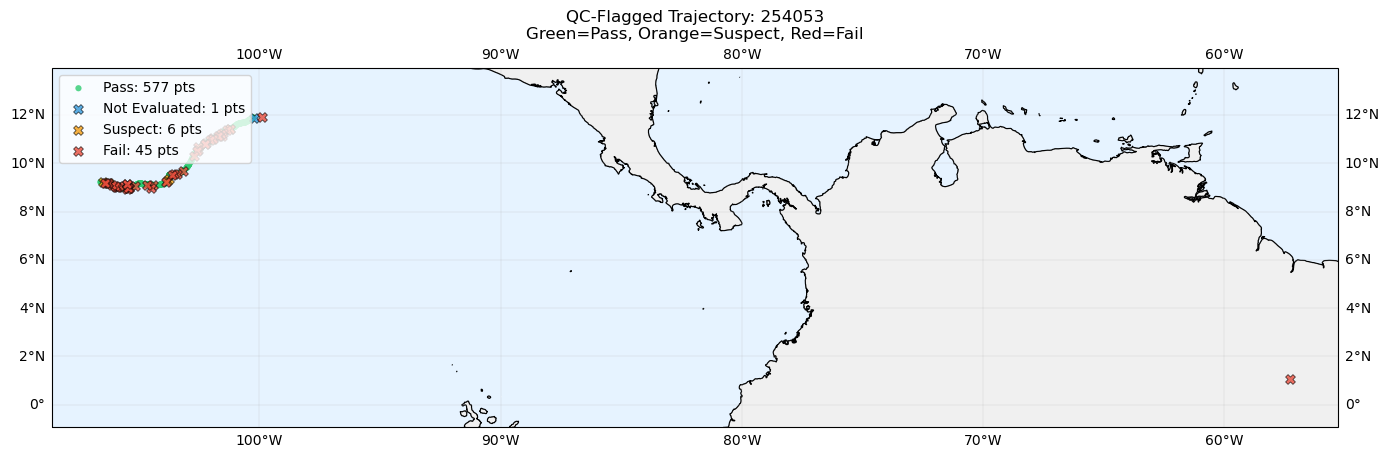

In [42]:
# Create a map showing QC-flagged trajectory
fig, ax = plt.subplots(1, 1, figsize=(14, 10), subplot_kw={'projection': ccrs.PlateCarree()})

# Use only valid coordinates for extent calculation
valid_coords = qc_df[(qc_df['lat'].between(-90, 90)) & (qc_df['lon'].between(-180, 180))]
lon_min = valid_coords['lon'].min() - 2
lon_max = valid_coords['lon'].max() + 2
lat_min = valid_coords['lat'].min() - 2
lat_max = valid_coords['lat'].max() + 2

ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND, facecolor='#f0f0f0', edgecolor='gray')
ax.add_feature(cfeature.OCEAN, facecolor='#e6f3ff')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

# Define colors for each flag value
flag_colors = {1: '#2ecc71', 2: '#3498db', 3: '#f39c12', 4: '#e74c3c', 9: '#95a5a6'}
flag_labels = {1: 'Pass', 2: 'Not Evaluated', 3: 'Suspect', 4: 'Fail', 9: 'Missing'}

# Plot trajectory line for good points only
good_mask = qc_df['qc_aggregate'] == 1
ax.plot(qc_df.loc[good_mask, 'lon'], qc_df.loc[good_mask, 'lat'],
        'g-', linewidth=0.5, alpha=0.3, transform=ccrs.PlateCarree())

# Plot points colored by QC flag
for flag_val in sorted(qc_df['qc_aggregate'].unique()):
    mask = qc_df['qc_aggregate'] == flag_val
    subset = qc_df[mask]
    valid_subset = subset[(subset['lat'].between(-90, 90)) & (subset['lon'].between(-180, 180))]
    
    if len(valid_subset) > 0:
        ax.scatter(valid_subset['lon'], valid_subset['lat'],
                   c=flag_colors.get(flag_val, 'gray'),
                   s=50 if flag_val > 1 else 20,
                   marker='o' if flag_val == 1 else 'X',
                   transform=ccrs.PlateCarree(),
                   label=f"{flag_labels.get(flag_val, f'Unknown')}: {len(subset)} pts",
                   zorder=5 if flag_val > 1 else 4,
                   edgecolors='black' if flag_val > 1 else 'none',
                   linewidths=0.5,
                   alpha=0.8)

# Get deployment ID
deploy_id = qc_df['DeployID'].iloc[0] if 'DeployID' in qc_df.columns else 'Deployment'

ax.legend(loc='upper left', fontsize=10)
ax.set_title(f"QC-Flagged Trajectory: {deploy_id}\nGreen=Pass, Orange=Suspect, Red=Fail", fontsize=12)
plt.tight_layout()
plt.show()

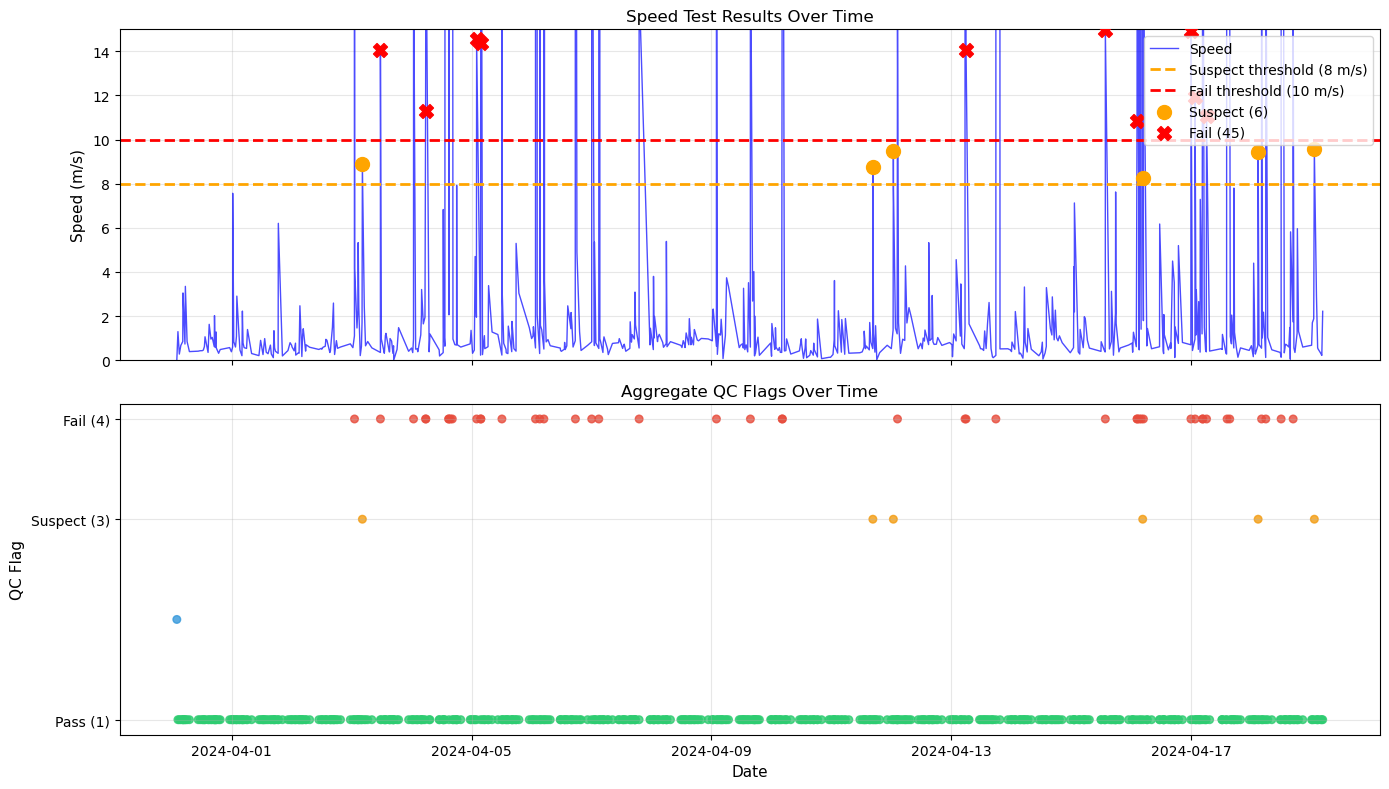

In [43]:
# Create speed time series plot
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Plot 1: Speed over time with thresholds
ax1 = axes[0]
ax1.plot(qc_df['time'], qc_df['calculated_speed'], 'b-', alpha=0.7, linewidth=1, label='Speed')
ax1.axhline(y=8.0, color='orange', linestyle='--', linewidth=2, label='Suspect threshold (8 m/s)')
ax1.axhline(y=10.0, color='red', linestyle='--', linewidth=2, label='Fail threshold (10 m/s)')

# Highlight flagged points
suspect_mask = qc_df['speed_test'] == 3
fail_mask = qc_df['speed_test'] == 4
if suspect_mask.any():
    ax1.scatter(qc_df.loc[suspect_mask, 'time'], qc_df.loc[suspect_mask, 'calculated_speed'],
                c='orange', s=100, marker='o', zorder=5, label=f'Suspect ({suspect_mask.sum()})')
if fail_mask.any():
    ax1.scatter(qc_df.loc[fail_mask, 'time'], qc_df.loc[fail_mask, 'calculated_speed'],
                c='red', s=100, marker='X', zorder=5, label=f'Fail ({fail_mask.sum()})')

ax1.set_ylabel('Speed (m/s)', fontsize=11)
ax1.set_title('Speed Test Results Over Time', fontsize=12)
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Set reasonable y-limit
max_speed = qc_df['calculated_speed'].quantile(0.99) if len(qc_df) > 10 else qc_df['calculated_speed'].max()
ax1.set_ylim(0, min(max_speed * 1.5, 15))

# Plot 2: QC flag values over time  
ax2 = axes[1]
flag_colors_map = {1: '#2ecc71', 3: '#f39c12', 4: '#e74c3c', 9: '#95a5a6'}
colors = [flag_colors_map.get(f, '#3498db') for f in qc_df['qc_aggregate']]
ax2.scatter(qc_df['time'], qc_df['qc_aggregate'], c=colors, s=30, alpha=0.8)
ax2.set_ylabel('QC Flag', fontsize=11)
ax2.set_xlabel('Date', fontsize=11)
ax2.set_yticks([1, 3, 4])
ax2.set_yticklabels(['Pass (1)', 'Suspect (3)', 'Fail (4)'])
ax2.set_title('Aggregate QC Flags Over Time', fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Export QC-Flagged Data

Finally, let's export the QC results. The flagged data can be saved in various formats for downstream analysis or archival.

In [44]:
# Create output dataframe with QC flags
output_df = qc_df[['time', 'lat', 'lon', 'location_test', 'speed_test', 'qc_aggregate', 'calculated_speed']].copy()

# Add original columns if present
for col in ['DeployID', 'Ptt', 'Quality', 'Type']:
    if col in qc_df.columns:
        output_df[col] = qc_df[col]

# Reorder columns
col_order = [c for c in ['DeployID', 'Ptt', 'time', 'lat', 'lon', 'Type', 'Quality', 
                          'calculated_speed', 'location_test', 'speed_test', 'qc_aggregate'] 
             if c in output_df.columns]
output_df = output_df[col_order]

print("QC-Flagged Output Data:")
print(f"  Total records: {len(output_df)}")
print(f"  Columns: {list(output_df.columns)}")
print("\nSample output:")
output_df.head(10)

QC-Flagged Output Data:
  Total records: 629
  Columns: ['DeployID', 'Ptt', 'time', 'lat', 'lon', 'Type', 'Quality', 'calculated_speed', 'location_test', 'speed_test', 'qc_aggregate']

Sample output:


,DeployID,Ptt,time,lat,lon,Type,Quality,calculated_speed,location_test,speed_test,qc_aggregate
0,254053,254053,2024-03-31 02:03:56,11.8863,-100.2372,Argos,0,0.000000,1,2,2
1,254053,254053,2024-03-31 02:30:43,11.9007,-100.2494,Argos,2,1.290994,1,1,1
2,254053,254053,2024-03-31 03:03:54,11.9024,-100.2447,Argos,1,0.273968,1,1,1
3,254053,254053,2024-03-31 03:40:08,11.8957,-100.2561,Argos,1,0.665268,1,1,1
4,254053,254053,2024-03-31 04:27:03,11.8882,-100.2766,Argos,2,0.846363,1,1,1
5,254053,254053,2024-03-31 04:31:31,11.8931,-100.2822,Argos,2,3.045184,1,1,1
6,254053,254053,2024-03-31 04:45:50,11.8744,-100.2820,Argos,1,2.408306,1,1,1
7,254053,254053,2024-03-31 05:19:02,11.8676,-100.2934,Argos,1,0.728967,1,1,1
8,254053,254053,2024-03-31 05:28:56,11.8851,-100.2893,Argos,1,3.344686,1,1,1
9,254053,254053,2024-03-31 06:10:26,11.8685,-100.2986,Argos,1,0.842295,1,1,1


In [45]:
# Save to CSV (uncomment to save)
# output_df.to_csv('trajectory_qc_results.csv', index=False)
# print("Saved to trajectory_qc_results.csv")

# Filter to only good data
good_data = output_df[output_df['qc_aggregate'] == 1]
print(f"\nFiltered to PASS flags only: {len(good_data)} of {len(output_df)} records retained")
print(f"Data retention rate: {100*len(good_data)/len(output_df):.1f}%")

# Summary of flagged points
print("\n" + "="*60)
print("FINAL QC SUMMARY")
print("="*60)
print(f"\nDeployment: {output_df['DeployID'].iloc[0] if 'DeployID' in output_df.columns else 'Unknown'}")
print(f"Date range: {output_df['time'].min()} to {output_df['time'].max()}")
print(f"Total points: {len(output_df)}")
print(f"\nQC Results:")
print(f"  ✓ PASS:    {(output_df['qc_aggregate']==1).sum():4d} ({100*(output_df['qc_aggregate']==1).sum()/len(output_df):.1f}%)")
print(f"  ? SUSPECT: {(output_df['qc_aggregate']==3).sum():4d} ({100*(output_df['qc_aggregate']==3).sum()/len(output_df):.1f}%)")
print(f"  ✗ FAIL:    {(output_df['qc_aggregate']==4).sum():4d} ({100*(output_df['qc_aggregate']==4).sum()/len(output_df):.1f}%)")


Filtered to PASS flags only: 577 of 629 records retained
Data retention rate: 91.7%

FINAL QC SUMMARY

Deployment: 254053
Date range: 2024-03-31 02:03:56 to 2024-04-19 04:35:53
Total points: 629

QC Results:
  ✓ PASS:     577 (91.7%)
  ? SUSPECT:    6 (1.0%)
  ✗ FAIL:      45 (7.2%)


## 8. Profile Data QC (Temperature and Depth)

Many Wildlife Computers tags also collect **time-series data** including temperature and depth measurements. For this example, we'll use the `SST.csv` file which contains temperature measurements.

For profile/time-series data, the ATN DAC applies QARTOD tests:

| Test | Variable | Fail Range | Description |
|------|----------|------------|-------------|
| `gross_range_test` | Temperature | [-2.5, 40] °C | Physical bounds for seawater temperature |
| `gross_range_test` | Salinity | [0, 41] PSU | Physical bounds for seawater salinity |
| `valid_range_test` | Time | Deployment period | Flags data outside deployment dates |

Let's load the SST data from our deployment.

In [46]:
# Load SST (Sea Surface Temperature) data for profile QC
# SST.csv contains temperature measurements at or near the surface

# List all CSV files in the deployment
all_csv_files = [f for f in zf.namelist() if f.endswith('.csv')]
print("CSV files in deployment ZIP:")
for f in sorted(all_csv_files):
    print(f"  - {f}")

# Find SST file using our helper function
sst_file = [f for f in all_csv_files if 'sst' in f.lower() and f.endswith('.csv')]

profile_df = None
if sst_file:
    print(f"\n✓ Found SST data: {sst_file}")
    with zf.open(sst_file[0]) as f:
        profile_df = pd.read_csv(f)
    print(f"  Loaded {len(profile_df)} records")
    print(f"\nColumns: {list(profile_df.columns)}")
    display(profile_df.head())
else:
    print("\n⚠ No SST.csv found in this deployment")
    print("  (This deployment may be trajectory-only)")

CSV files in deployment ZIP:
  - 254053O2024/254053-10-GPE3.csv
  - 254053O2024/254053-All.csv
  - 254053O2024/254053-Argos.csv
  - 254053O2024/254053-Corrupt.csv
  - 254053O2024/254053-Histos.csv
  - 254053O2024/254053-Labels.csv
  - 254053O2024/254053-LightLoc.csv
  - 254053O2024/254053-Locations.csv
  - 254053O2024/254053-MinMaxDepth.csv
  - 254053O2024/254053-MixLayer.csv
  - 254053O2024/254053-PDTs.csv
  - 254053O2024/254053-RTC.csv
  - 254053O2024/254053-RawArgos.csv
  - 254053O2024/254053-SST.csv
  - 254053O2024/254053-Series.csv
  - 254053O2024/254053-SeriesRange.csv
  - 254053O2024/254053-Status.csv
  - 254053O2024/254053-Summary.csv

✓ Found SST data: ['254053O2024/254053-SST.csv']
  Loaded 1019 records

Columns: ['DeployID', 'Ptt', 'DepthSensor', 'Instr', 'Date', 'LocationQuality', 'Latitude', 'Longitude', 'Depth', 'Temperature', 'Source']


,DeployID,Ptt,DepthSensor,Instr,Date,LocationQuality,Latitude,Longitude,Depth,Temperature,Source
0,254053,254053,0.5,MiniPAT,20:00:00 16-Jan-2024,NaN,NaN,NaN,0.4,29.3,TimeSeries
1,254053,254053,0.5,MiniPAT,00:00:00 17-Jan-2024,NaN,NaN,NaN,0.4,28.3,TimeSeries
2,254053,254053,0.5,MiniPAT,01:00:00 17-Jan-2024,NaN,NaN,NaN,0.4,28.3,TimeSeries
3,254053,254053,0.5,MiniPAT,02:00:00 17-Jan-2024,NaN,NaN,NaN,0.4,28.3,TimeSeries
4,254053,254053,0.5,MiniPAT,04:00:00 17-Jan-2024,NaN,NaN,NaN,0.4,28.0,TimeSeries


In [47]:
# If we have profile/series data, apply QC tests
# This mirrors the QC applied in packrat/platforms/utils.py default_qc_config()

if profile_df is not None and len(profile_df) > 0:
    # Find temperature column (various naming conventions)
    temp_col = None
    depth_col = None
    time_col = None
    
    for col in profile_df.columns:
        col_lower = col.lower()
        if 'temp' in col_lower and temp_col is None:
            temp_col = col
        if 'depth' in col_lower and depth_col is None:
            depth_col = col
        if 'date' in col_lower or 'time' in col_lower:
            time_col = col
    
    print(f"Identified columns:")
    print(f"  Temperature: {temp_col}")
    print(f"  Depth: {depth_col}")
    print(f"  Time: {time_col}")
    
    # Prepare profile dataframe for QC
    profile_qc_df = profile_df.copy()
    
    if time_col:
        profile_qc_df['time'] = pd.to_datetime(profile_qc_df[time_col])
        profile_qc_df = profile_qc_df.sort_values('time').reset_index(drop=True)
    
    # Standardize column names for QC
    if temp_col:
        profile_qc_df['temperature'] = pd.to_numeric(profile_qc_df[temp_col], errors='coerce')
    if depth_col:
        profile_qc_df['depth'] = pd.to_numeric(profile_qc_df[depth_col], errors='coerce')
    
    print(f"\nProfile data prepared for QC: {len(profile_qc_df)} records")
    
    if temp_col:
        print(f"\nTemperature statistics:")
        print(f"  Min: {profile_qc_df['temperature'].min():.2f} °C")
        print(f"  Max: {profile_qc_df['temperature'].max():.2f} °C")
        print(f"  Mean: {profile_qc_df['temperature'].mean():.2f} °C")
else:
    print("No profile data available for QC demonstration")

Identified columns:
  Temperature: Temperature
  Depth: DepthSensor
  Time: Date

Profile data prepared for QC: 1019 records

Temperature statistics:
  Min: 17.40 °C
  Max: 32.60 °C
  Mean: 28.35 °C


### Apply Gross Range Test to Temperature

The **gross_range_test** checks if values fall within physically plausible bounds. For temperature, the ATN DAC uses the Argo QC Manual thresholds:
- **Fail bounds**: [-2.5, 40] °C (values outside this range are flagged as FAIL)

This test catches sensor malfunctions that report impossible temperatures.

In [48]:
# Apply gross_range_test to temperature data
# This matches the QC in packrat/platforms/utils.py

from ioos_qc.qartod import gross_range_test

if profile_df is not None and 'temperature' in profile_qc_df.columns:
    # ATN DAC thresholds from Argo QC Manual
    # See: packrat/platforms/utils.py default_qc_config()
    TEMP_FAIL_MIN = -2.5
    TEMP_FAIL_MAX = 40.0
    
    temp_flags = gross_range_test(
        inp=profile_qc_df['temperature'].values,
        fail_span=[TEMP_FAIL_MIN, TEMP_FAIL_MAX]
    )
    
    profile_qc_df['temperature_qartod_gross_range_test'] = temp_flags
    
    print("Temperature Gross Range Test Results")
    print("="*50)
    print(f"Fail bounds: [{TEMP_FAIL_MIN}, {TEMP_FAIL_MAX}] °C")
    print(f"\nFlag distribution:")
    flag_names = {1: 'PASS', 2: 'NOT_EVAL', 3: 'SUSPECT', 4: 'FAIL', 9: 'MISSING'}
    for flag, count in pd.Series(temp_flags).value_counts().sort_index().items():
        pct = 100 * count / len(temp_flags)
        print(f"  {flag_names.get(flag, 'UNK')} ({flag}): {count:5d} ({pct:.1f}%)")
    
    # Show any failed values
    failed_temp = profile_qc_df[profile_qc_df['temperature_qartod_gross_range_test'] == 4]
    if len(failed_temp) > 0:
        print(f"\n⚠ {len(failed_temp)} temperature values failed gross_range_test:")
        print(failed_temp[['time', 'temperature', 'temperature_qartod_gross_range_test']].head(10))
    else:
        print(f"\n✓ All temperature values passed the gross_range_test")
else:
    print("No temperature data available for QC")

Temperature Gross Range Test Results
Fail bounds: [-2.5, 40.0] °C

Flag distribution:
  PASS (1):  1019 (100.0%)

✓ All temperature values passed the gross_range_test


### Apply Valid Range Test to Time

The **valid_range_test** checks that observations fall within the deployment period. This catches data with timestamp errors or data logged before/after the tag was deployed.

In [49]:
# Apply valid_range_test to time
# This uses ioos_qc.axds.valid_range_test as used in packrat

from ioos_qc.axds import valid_range_test

if profile_df is not None and 'time' in profile_qc_df.columns:
    # Define deployment period from the data itself
    # In production, these come from the PI-specified dates in ADR
    deploy_start = profile_qc_df['time'].min()
    deploy_end = profile_qc_df['time'].max()
    
    print(f"Deployment period: {deploy_start} to {deploy_end}")
    
    # Convert to ISO format strings as expected by valid_range_test
    time_flags = valid_range_test(
        inp=profile_qc_df['time'].values,
        valid_span=[
            deploy_start.isoformat(),
            deploy_end.isoformat()
        ]
    )
    
    profile_qc_df['time_axds_valid_range_test'] = time_flags
    
    print("\nTime Valid Range Test Results")
    print("="*50)
    flag_names = {1: 'PASS', 2: 'NOT_EVAL', 3: 'SUSPECT', 4: 'FAIL', 9: 'MISSING'}
    for flag, count in pd.Series(time_flags).value_counts().sort_index().items():
        pct = 100 * count / len(time_flags)
        print(f"  {flag_names.get(flag, 'UNK')} ({flag}): {count:5d} ({pct:.1f}%)")
else:
    print("No time data available for valid_range_test")

Deployment period: 2024-01-16 20:00:00 to 2024-04-19 00:00:00

Time Valid Range Test Results
  PASS (1):  1018 (99.9%)
  FAIL (4):     1 (0.1%)


### Using PandasStream for Batch QC (Production Approach)

In the ATN DAC production pipeline (packrat), QC tests are run using `ioos_qc`'s `PandasStream` and `PandasStore` classes. This approach:
1. Applies all configured tests in a single pass
2. Automatically computes aggregate (rollup) flags
3. Produces standardized output column names

Here's how packrat runs QC:

In [50]:
# Production QC approach using PandasStream (as used in packrat)
# This mirrors packrat/platforms/utils.py apply_qc() function

def apply_qc_packrat_style(df, qc_config_yaml):
    """
    Apply QC using the same approach as packrat.
    
    This function mirrors packrat/platforms/utils.py apply_qc()
    """
    # Parse the YAML config
    config = Config(qc_config_yaml)
    
    # Setup the stream
    stream = PandasStream(df)
    
    # Run the tests
    results = stream.run(config)
    
    # Store the results
    store = PandasStore(
        results,
        axes={
            't': 'time',
            'z': 'z' if 'z' in df.columns else None,
            'y': 'lat' if 'lat' in df.columns else None,
            'x': 'lon' if 'lon' in df.columns else None
        }
    )
    
    # Compute aggregate rollup flag
    store.compute_aggregate(name='qartod_rollup_qc')
    
    # Get results as DataFrame
    results_df = store.save(write_data=False, write_axes=False)
    
    # Append QC columns to original data
    return pd.concat([df, results_df], axis=1)

# Example: Define QC config for profile data (matching packrat defaults)
if profile_df is not None and 'temperature' in profile_qc_df.columns:
    
    # Get deployment time bounds
    deploy_start = profile_qc_df['time'].min().isoformat()
    deploy_end = profile_qc_df['time'].max().isoformat()
    
    # Build QC configuration YAML (same format as packrat)
    profile_qc_yaml = f"""
    time:
        axds:
            valid_range_test:
                valid_span:
                    - {deploy_start}
                    - {deploy_end}
    temperature:
        qartod:
            gross_range_test:
                fail_span: [-2.5, 40]
    """
    
    print("QC Configuration (YAML format):")
    print(profile_qc_yaml)
    
    # Run QC
    profile_qc_results = apply_qc_packrat_style(profile_qc_df, profile_qc_yaml)
    
    print("\n" + "="*50)
    print("QC Results (packrat-style)")
    print("="*50)
    
    # Show QC columns added
    qc_cols = [c for c in profile_qc_results.columns if 'qc' in c.lower() or 'test' in c.lower()]
    print(f"\nQC columns added: {qc_cols}")
    
    # Show rollup summary
    if 'qartod_rollup_qc' in profile_qc_results.columns:
        print(f"\nAggregate QC (qartod_rollup_qc) distribution:")
        for flag, count in profile_qc_results['qartod_rollup_qc'].value_counts().sort_index().items():
            pct = 100 * count / len(profile_qc_results)
            flag_names = {1: 'PASS', 2: 'NOT_EVAL', 3: 'SUSPECT', 4: 'FAIL', 9: 'MISSING'}
            print(f"  {flag_names.get(flag, 'UNK')} ({flag}): {count:5d} ({pct:.1f}%)")
else:
    print("No profile data available for demonstration")

QC Configuration (YAML format):

    time:
        axds:
            valid_range_test:
                valid_span:
                    - 2024-01-16T20:00:00
                    - 2024-04-19T00:00:00
    temperature:
        qartod:
            gross_range_test:
                fail_span: [-2.5, 40]
    

QC Results (packrat-style)

QC columns added: ['temperature_qartod_gross_range_test', 'time_axds_valid_range_test', 'time_axds_valid_range_test', 'temperature_qartod_gross_range_test', 'qartod_qartod_rollup_qc']


### Visualize Profile QC Results

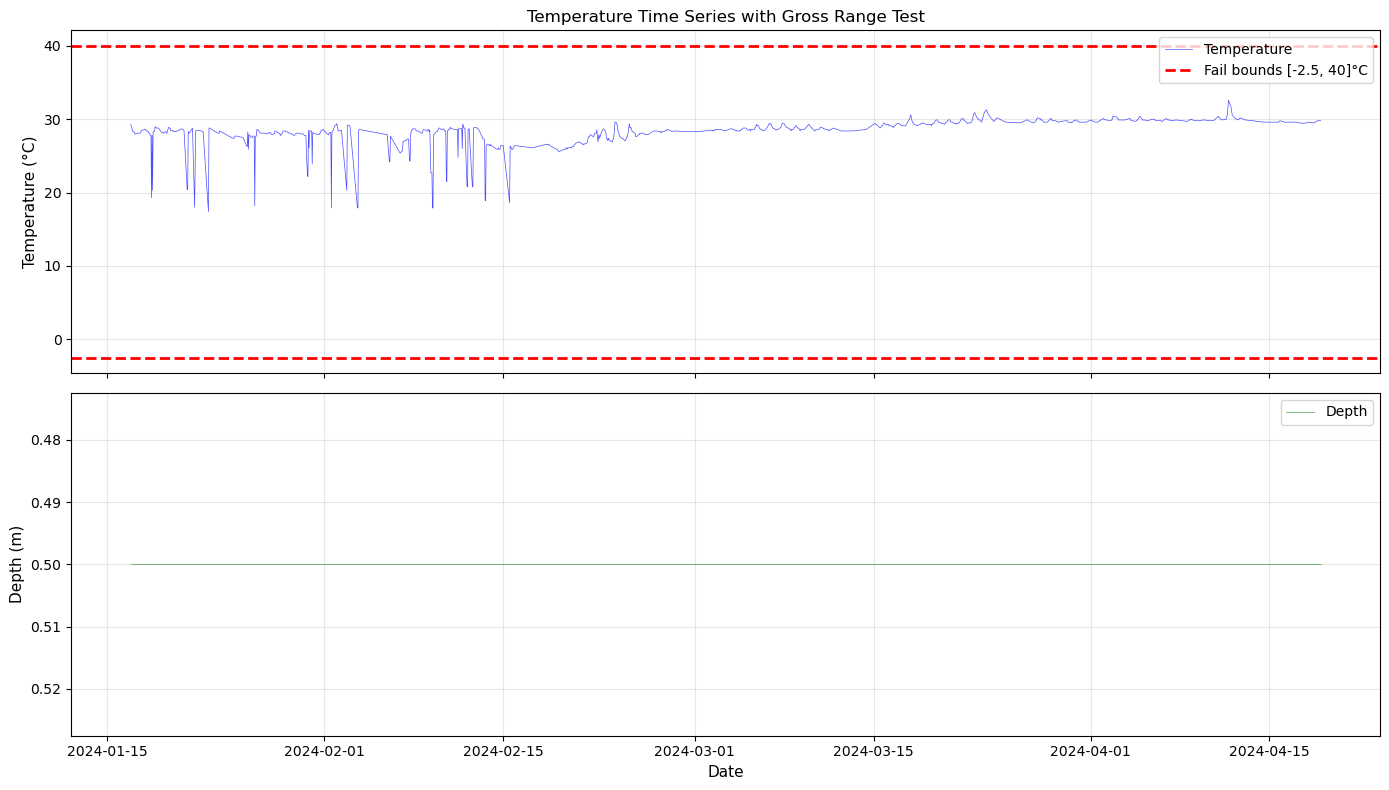

In [51]:
# Visualize temperature time series with QC flags
if profile_df is not None and 'temperature' in profile_qc_df.columns:
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    
    # Plot 1: Temperature time series with QC thresholds
    ax1 = axes[0]
    ax1.plot(profile_qc_df['time'], profile_qc_df['temperature'], 
             'b-', alpha=0.7, linewidth=0.5, label='Temperature')
    
    # Show QC thresholds
    ax1.axhline(y=-2.5, color='red', linestyle='--', linewidth=2, 
                label='Fail bounds [-2.5, 40]°C')
    ax1.axhline(y=40, color='red', linestyle='--', linewidth=2)
    
    # Highlight any failed points
    if 'temperature_qartod_gross_range_test' in profile_qc_df.columns:
        fail_mask = profile_qc_df['temperature_qartod_gross_range_test'] == 4
        if fail_mask.any():
            ax1.scatter(profile_qc_df.loc[fail_mask, 'time'], 
                       profile_qc_df.loc[fail_mask, 'temperature'],
                       c='red', s=50, marker='X', zorder=5, 
                       label=f'Failed ({fail_mask.sum()})')
    
    ax1.set_ylabel('Temperature (°C)', fontsize=11)
    ax1.set_title('Temperature Time Series with Gross Range Test', fontsize=12)
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Depth if available
    ax2 = axes[1]
    if 'depth' in profile_qc_df.columns:
        ax2.plot(profile_qc_df['time'], profile_qc_df['depth'], 
                 'g-', alpha=0.7, linewidth=0.5, label='Depth')
        ax2.set_ylabel('Depth (m)', fontsize=11)
        ax2.invert_yaxis()  # Depth increases downward
        ax2.legend(loc='upper right')
    else:
        ax2.text(0.5, 0.5, 'No depth data available', ha='center', va='center',
                transform=ax2.transAxes, fontsize=12, color='gray')
    
    ax2.set_xlabel('Date', fontsize=11)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("No profile data available for visualization")

## 9. Summary

This notebook demonstrated the QARTOD QC tests applied by the ATN Data Assembly Center to animal telemetry data. The key tests are:

### Trajectory QC
| Test | Module | Thresholds | Purpose |
|------|--------|------------|---------|
| `location_test` | `ioos_qc.qartod` | bbox: [-180, -90, 180, 90] | Valid geographic bounds |
| `speed_test` | `ioos_qc.argo` | suspect: 8 m/s, fail: 10 m/s | Realistic movement speeds |

### Profile/Time-Series QC  
| Test | Module | Thresholds | Purpose |
|------|--------|------------|---------|
| `gross_range_test` | `ioos_qc.qartod` | temp: [-2.5, 40]°C | Physical sensor bounds |
| `gross_range_test` | `ioos_qc.qartod` | salinity: [0, 41] PSU | Physical sensor bounds |
| `valid_range_test` | `ioos_qc.axds` | deployment dates | Deployment period bounds |

### Production Implementation

The ATN DAC pipeline (packrat) uses:
- `ioos_qc.streams.PandasStream` to run tests
- `ioos_qc.stores.PandasStore` to store results
- `qartod_rollup_qc` aggregate flag combining all test results

QC flags are added as columns to the data (e.g., `temperature_qartod_gross_range_test`) and included in the final NetCDF files distributed via the ATN Data Portal.

---

### References

- [ATN Data Portal](https://portal.atn.ioos.us/)
- [IOOS QARTOD Manual](https://ioos.noaa.gov/project/qartod/)
- [ioos_qc Documentation](https://ioos.github.io/ioos_qc/)
- [Argo Quality Control Manual](https://archimer.ifremer.fr/doc/00228/33951/)
- [Wildlife Computers Data Portal](https://my.wildlifecomputers.com/)
- [ATN DAC Specification](https://github.com/ioos/ioos-atn-data/wiki/ATN-DAC-Specification)